## 다층 퍼셉트론(Multilayer perceptron, MLP), 입력층과 출력층 사이에 은닉층을 가진 퍼셉트론

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

### 3.0. 활성화 함수(Activation function)

### 3.1. MLP의 순방향 패스 (Forward pass)

### 3.2. 손실함수(Loss function)

- 신경망에서 학습시킬 때 실제 출력과 원하는 출력(예측) 사이의 오차를 통해 학습 성과 측정 지표
- 평균 제곱 오차(Mean Squared Error) : 예측값과 정답 간 평균 제곱 오차
$$E(w) = \frac{1}{2} \Sigma_i (y_i - t_i)^2$$

In [6]:
y = np.array( [0.0, 0.0, 0.8, 0.1, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0] )
target = np.array( [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] )

y_ = np.array( [0.9, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] )
target_ = np.array( [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] )

In [7]:
def MeanSquaredError(target, y):
    """예측값과 정답 간의 평균 제곱 오차(MSE) 계산 메서드"""
    return 0.5 * np.sum( (y - target)**2 )

In [10]:
print(
    MeanSquaredError(target, y), # 예측값과 정답 간의 평균 제곱 오차
    MeanSquaredError(target_, y_) # 예측값과 정답이 많이 차이나는 경우
)

0.029999999999999992 0.81


### 3.3. 경사하강법(Gradient Descent)

- 예측값과 정답이 차이가 많이 나는 경우 등 손실함수 값을 최소로 하는 가중치를 찾는 목표
- 즉, 신경망 학습 = **최적화(Optimization) 문제**
  - 손실함수를 가중치로 미분한 값이 양수이면, 가중치 감소시킴
  - 손실함수를 가중치로 미분한 값이 음수이면, 가중치 증가시킴

In [11]:
x = 10               # 시작 위치(초기값)
learning_rate = 0.2  # 학습률: 한 번에 이동하는 보폭 (너무 크면 발산, 너무 작으면 느림)
                     # 학습률이 1.0을 넘으면 |1 - 2×lr| > 1이 되어 발산해요.
precision = 0.00001  # 허용 오차: 이동량이 이 값보다 작으면 수렴했다고 판단
max_iterations = 100 # 최대 반복 횟수

loss_function = lambda x: (x - 3)**2 + 10
# 손실함수: f(x) = (x-3)^2 + 10 → x=3일 때 최솟값 10

gradient = lambda x: 2*x - 6
# 손실함수의 1차 미분(기울기): f'(x) = 2(x-3) = 2x - 6

for i in range(max_iterations):
    x -= learning_rate * gradient(x)
    # 학습률 * 기울기만큼 이동
    # 기울기의 반대 방향(내리막)으로 이동
    print("손실함수값(", x, ")=", loss_function(x))

    # if abs( learning_rate * gradient(x) ) < precision:
        # 조기 종료 조건
        # break


print("최소값 = ", x) 
# 최소값 =  3.0000000000000004
# 최종 x (3에 가까워짐)

손실함수값( 7.199999999999999 )= 27.639999999999993
손실함수값( 5.52 )= 16.350399999999997
손실함수값( 4.512 )= 12.286143999999998
손실함수값( 3.9071999999999996 )= 10.82301184
손실함수값( 3.54432 )= 10.2962842624
손실함수값( 3.3265919999999998 )= 10.106662334464
손실함수값( 3.1959551999999998 )= 10.03839844040704
손실함수값( 3.11757312 )= 10.013823438546535
손실함수값( 3.070543872 )= 10.004976437876753
손실함수값( 3.0423263232 )= 10.001791517635631
손실함수값( 3.02539579392 )= 10.000644946348826
손실함수값( 3.015237476352 )= 10.000232180685577
손실함수값( 3.0091424858112 )= 10.000083585046807
손실함수값( 3.00548549148672 )= 10.000030090616852
손실함수값( 3.003291294892032 )= 10.000010832622067
손실함수값( 3.0019747769352194 )= 10.000003899743945
손실함수값( 3.0011848661611316 )= 10.00000140390782
손실함수값( 3.000710919696679 )= 10.000000505406815
손실함수값( 3.0004265518180073 )= 10.000000181946453
손실함수값( 3.0002559310908046 )= 10.000000065500723
손실함수값( 3.0001535586544827 )= 10.00000002358026
손실함수값( 3.0000921351926895 )= 10.000000008488893
손실함수값( 3.0000552811156136 )= 10.000000

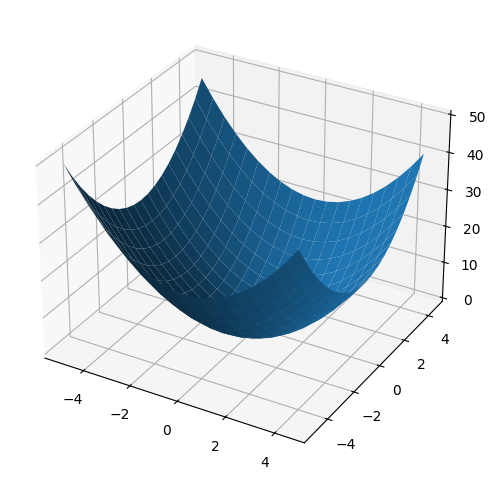

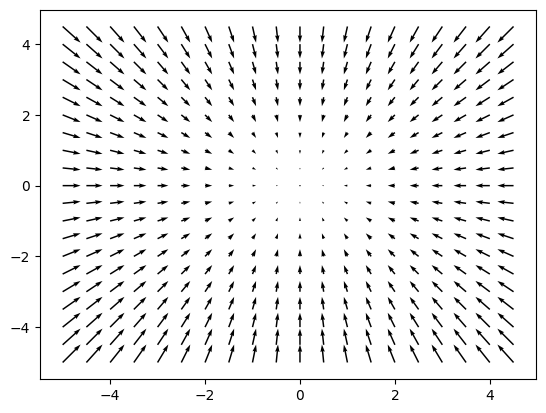

In [14]:
# 2차원 gradient 시각화 (1)

x_arange = np.arange(-5, 5, 0.5) 
y_arange = np.arange(-5, 5, 0.5)
# x, y축 범위: -5 ~ 4.5, 간격 0.5

X, Y = np.meshgrid(x_arange, y_arange)
Z = X**2 + Y**2
# 3D 곡면 시각화: Z = X^2 + Y^2

fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(111, projection = "3d")

ax.plot_surface(X, Y, Z)
plt.show()


# 2차원 gradient 시각화 (2)

U = -2*X
V = -2*Y
# gradient의 음수

plt.figure()
Q = plt.quiver(X, Y, U, V, units = "width")
# 화살표가 최소값을 가리키는 그래프
plt.show()


### 3.4. 역전파 알고리즘(Back-propagation)

$$w(t+1) = w(t) - \eta \frac{\partial E}{\partial w}$$
- 입력이 주어지면 순방향으로 계산하여 출력을 계산함
- 실제 출력과 우리가 원하는 출력 간의 오차를 계산함
  - 입력층과 출력청 사이에 은닉층의 출력값에 대한 기준값을 정의할 수 없으므로, 
  - 은닉층에서 어떤 값이 출력되어야 맞다, 틀리다하는 기준이 없음
  - 따라서 출력층에서 발생하는 오차값에 따라 역방향으로 오차를 전파시키면서 각 은닉층의 가중치를 업데이트
- 이 오차를 역방향으로 전파하면서 오차를 줄이는 방향으로 가중치 변경

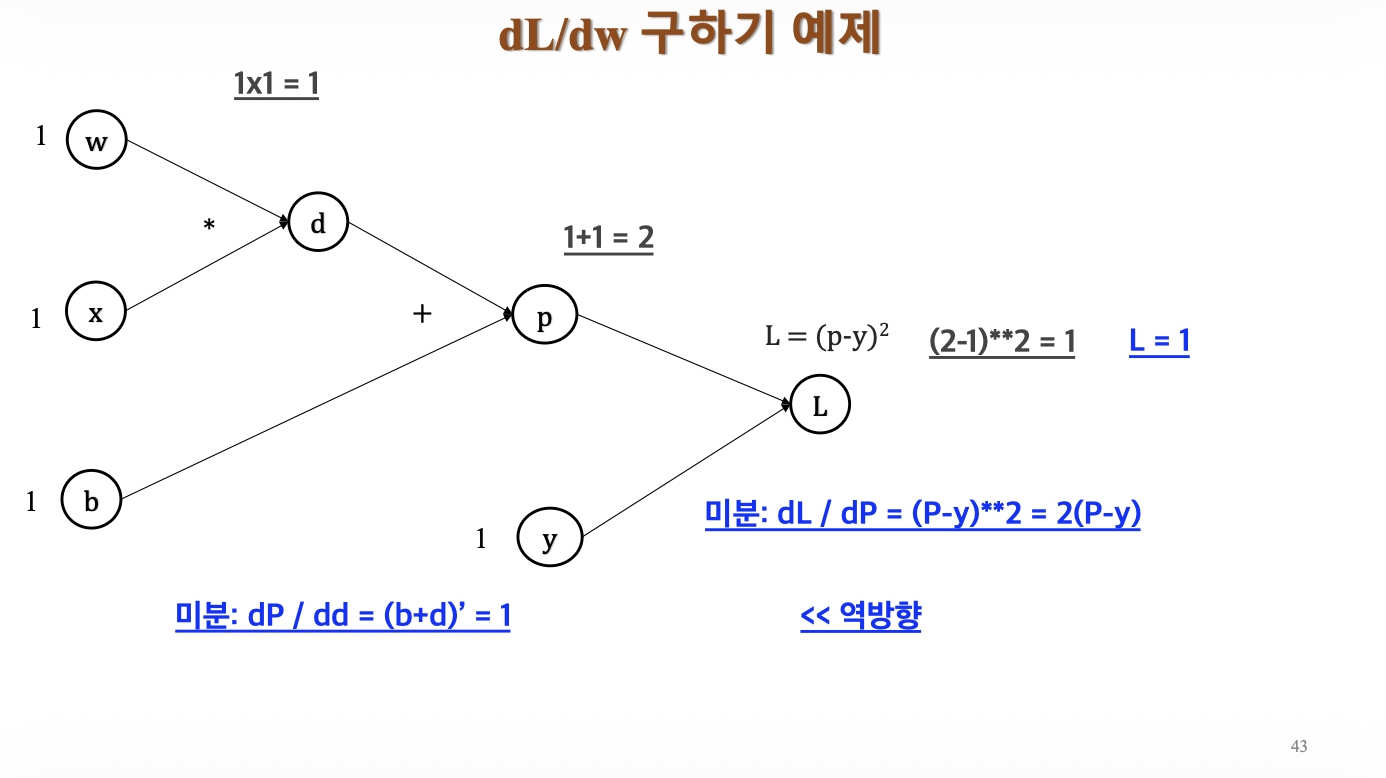

#### dL/dw 구하기 예제 풀이

L = (p−y)², p = d + b, d = w·x (모든 값 1)

[순방향]
-  d = 1, p = 2, L = 1

[역방향]
- 손실 노드: ∂L/∂p = 2(p−y) = 2
- 덧셈 노드(p = d + b): ∂p/∂d = 1이라 기울기 2가 그대로 d로 전달
- 곱셈 노드(d = w·x): ∂d/∂w = x = 1

[결과값]
- ∂L/∂w = 2 × 1 × 1 = 2

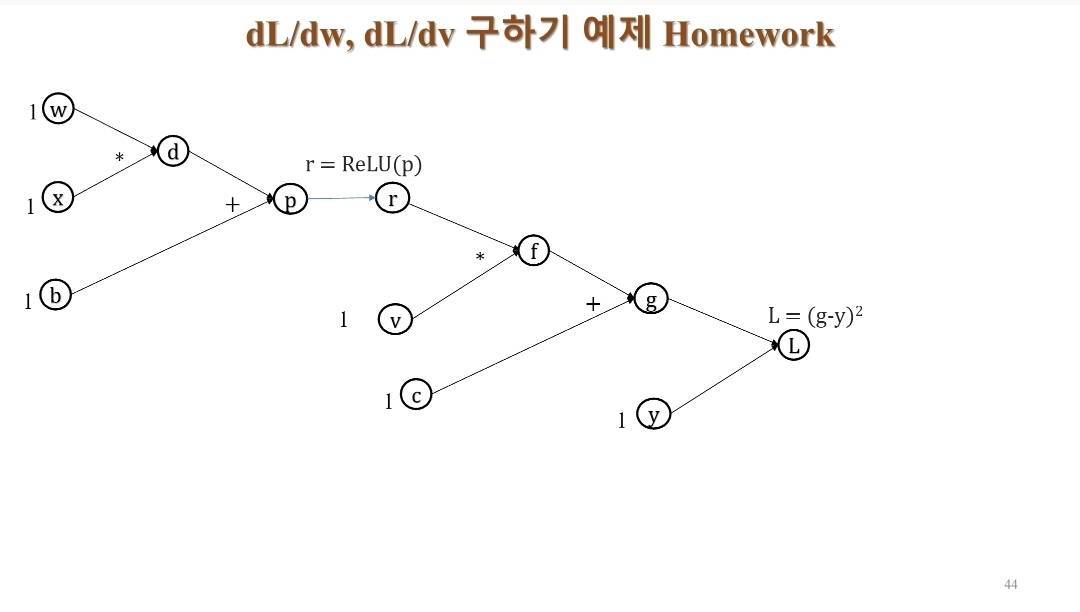

#### dL/dw, dL/dv 구하기 예제 풀이

d = w·x, p = d + b, r = ReLU(p), f = r·v, g = f + c, L = (g−y)² (모든 값 1)

[순방향]
- d = 1, p = 2, r = 2, f = 2, g = 3, L = 4

[역방향]
- 손실 노드: ∂L/∂g = 2(g−y) = 4
- 덧셈 노드(g = f + c): 기울기 4가 f로 그대로 전달
- 곱셈 노드(f = r·v):
  - v 쪽은 상대편 r을 곱함 → ∂L/∂v = 4 × r = 4 × 2 = 8
  - r 쪽은 상대편 v를 곱함 → ∂L/∂r = 4 × v = 4
- ReLU(r = ReLU(p)): p = 2 > 0이라 미분 1, 기울기 4 그대로 통과
- 덧셈 노드(p = d + b): 기울기 4가 d로 그대로 전달
- 곱셈 노드(d = w·x): 상대편 x를 곱함 → ∂L/∂w = 4 × x = 4 × 1 = 4